In [6]:
import torch
import torchvision
import torchvision.transforms as transforms

# --------------------------
# 1. 超参数与数据准备
# --------------------------
batch_size = 256
input_dim = 784    # Fashion-MNIST 28x28=784
hidden_dim = 256   # 隐藏层神经元数
output_dim = 10    # 10分类
lr = 0.1           # 学习率
epochs = 10

# 数据加载
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # 归一化到[-1,1]
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=batch_size, shuffle=False
)

# --------------------------
# 2. 手动初始化参数（正态分布随机初始化）
# --------------------------
# W1: [input_dim, hidden_dim], b1: [hidden_dim]
W1 = torch.randn(input_dim, hidden_dim) * 0.01  # 乘以小系数防止初始值过大
b1 = torch.zeros(hidden_dim)
# W2: [hidden_dim, output_dim], b2: [output_dim]
W2 = torch.randn(hidden_dim, output_dim) * 0.01
b2 = torch.zeros(output_dim)

# 开启梯度
W1.requires_grad = True
b1.requires_grad = True
W2.requires_grad = True
b2.requires_grad = True

# --------------------------
# 3. 实现 ReLU 激活函数
# --------------------------
def relu(x):
    return torch.max(torch.tensor(0.0), x)

# --------------------------
# 4. 实现 Softmax + 交叉熵损失
# --------------------------
def softmax(x):
    # 防止数值溢出，减去每一行的最大值
    max_vals, _ = torch.max(x, dim=1, keepdim=True)
    exp_x = torch.exp(x - max_vals)
    sum_exp_x = torch.sum(exp_x, dim=1, keepdim=True)
    return exp_x / sum_exp_x

def cross_entropy_loss(logits, labels):
    # logits: [batch_size, output_dim], labels: [batch_size]
    batch_size = logits.shape[0]
    probs = softmax(logits)
    # 取出对应类别的概率
    log_probs = -torch.log(probs[range(batch_size), labels])
    return torch.mean(log_probs)

# --------------------------
# 5. 训练循环（Mini-batch SGD）
# --------------------------
for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        # 数据展平: [batch_size, 1, 28, 28] -> [batch_size, 784]
        x = images.view(-1, input_dim)
        
        # --- 前向传播 ---
        h1 = relu(torch.matmul(x, W1) + b1)  # 隐藏层输出
        logits = torch.matmul(h1, W2) + b2   # 输出层logits
        loss = cross_entropy_loss(logits, labels)
        
        # --- 反向传播（自动求导）---
        loss.backward()
        
        # --- 手动更新参数（SGD）---
        with torch.no_grad():
            W1 -= lr * W1.grad
            b1 -= lr * b1.grad
            W2 -= lr * W2.grad
            b2 -= lr * b2.grad
            
            # 清空梯度
            W1.grad.zero_()
            b1.grad.zero_()
            W2.grad.zero_()
            b2.grad.zero_()
        
        # 统计训练信息
        running_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    # 每个epoch结束打印
    train_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}%")

# --------------------------
# 6. 测试模型
# --------------------------
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        x = images.view(-1, input_dim)
        h1 = relu(torch.matmul(x, W1) + b1)
        logits = torch.matmul(h1, W2) + b2
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy of the model on the 10000 test images: {100 * correct / total:.2f}%")

Epoch [1/10], Loss: 0.7762, Train Acc: 72.75%
Epoch [2/10], Loss: 0.4925, Train Acc: 82.07%
Epoch [3/10], Loss: 0.4418, Train Acc: 84.05%
Epoch [4/10], Loss: 0.4107, Train Acc: 85.12%
Epoch [5/10], Loss: 0.3876, Train Acc: 85.95%
Epoch [6/10], Loss: 0.3727, Train Acc: 86.45%
Epoch [7/10], Loss: 0.3578, Train Acc: 87.09%
Epoch [8/10], Loss: 0.3450, Train Acc: 87.54%
Epoch [9/10], Loss: 0.3356, Train Acc: 87.75%
Epoch [10/10], Loss: 0.3273, Train Acc: 88.17%
Test Accuracy of the model on the 10000 test images: 83.54%


=== 无正则化模型 ===
Epoch [1/10] | Train Loss: 0.7730 | Val Loss: 0.5963
Epoch [2/10] | Train Loss: 0.4886 | Val Loss: 0.4736
Epoch [3/10] | Train Loss: 0.4402 | Val Loss: 0.5609
Epoch [4/10] | Train Loss: 0.4076 | Val Loss: 0.4521
Epoch [5/10] | Train Loss: 0.3883 | Val Loss: 0.4159
Epoch [6/10] | Train Loss: 0.3685 | Val Loss: 0.4203
Epoch [7/10] | Train Loss: 0.3570 | Val Loss: 0.3836
Epoch [8/10] | Train Loss: 0.3439 | Val Loss: 0.4815
Epoch [9/10] | Train Loss: 0.3330 | Val Loss: 0.4027
Epoch [10/10] | Train Loss: 0.3228 | Val Loss: 0.4049

=== 带L2权重衰减模型 ===
Epoch [1/10] | Train Loss: 0.7734 | Val Loss: 0.5697
Epoch [2/10] | Train Loss: 0.4919 | Val Loss: 0.4837
Epoch [3/10] | Train Loss: 0.4471 | Val Loss: 0.4909
Epoch [4/10] | Train Loss: 0.4146 | Val Loss: 0.4761
Epoch [5/10] | Train Loss: 0.3955 | Val Loss: 0.4709
Epoch [6/10] | Train Loss: 0.3832 | Val Loss: 0.4242
Epoch [7/10] | Train Loss: 0.3648 | Val Loss: 0.4277
Epoch [8/10] | Train Loss: 0.3567 | Val Loss: 0.4130
Epoch [9/10

C:\Users\jimmy\AppData\Local\Temp\ipykernel_5448\620275328.py:185: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jimmy\AppData\Local\Temp\ipykernel_5448\620275328.py:185: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jimmy\AppData\Local\Temp\ipykernel_5448\620275328.py:185: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jimmy\AppData\Local\Temp\ipykernel_5448\620275328.py:185: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jimmy\AppData\Local\Temp\ipykernel_5448\620275328.py:185: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jimmy\AppData\Local\Temp\ipykernel_5448\620275328.py:185: UserWarning: Glyph 32447 (\N{CJK 

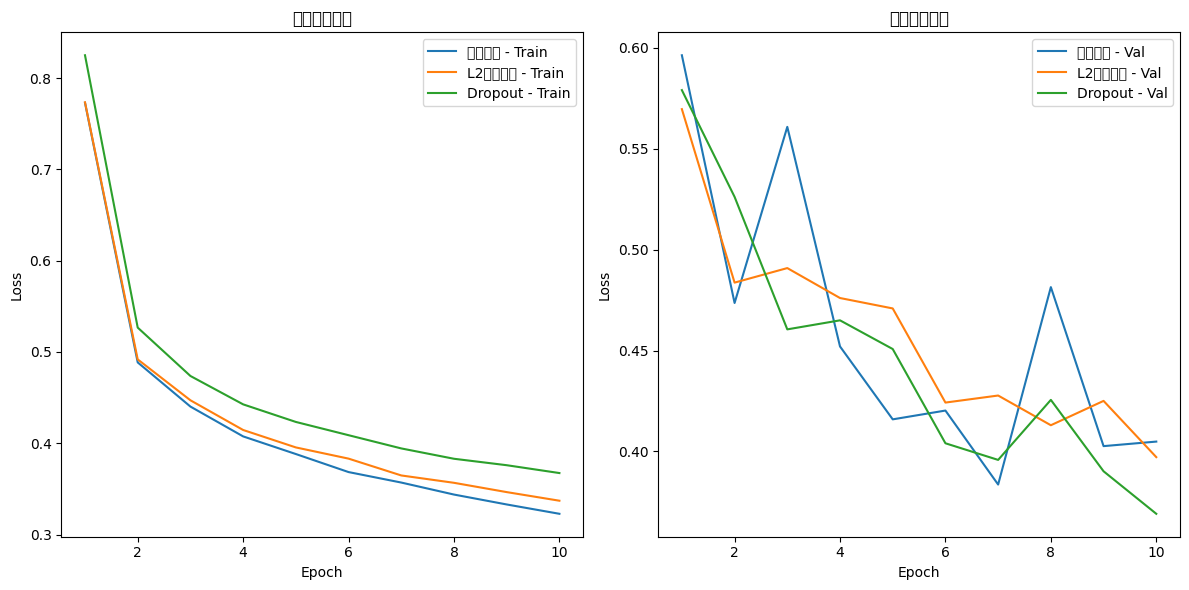

In [7]:
import matplotlib.pyplot as plt

# --------------------------
# 超参数与数据准备（Fashion-MNIST）
# --------------------------
batch_size = 256
input_dim = 784    # 28x28
hidden_dim = 256
output_dim = 10
lr = 0.1
epochs = 10
weight_decay = 0.001  # L2正则化系数λ
dropout_prob = 0.5    # Dropout概率

# 数据加载
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# --------------------------
# 1. 参数初始化（为三种情况分别创建参数）
# --------------------------
def init_params():
    W1 = torch.randn(input_dim, hidden_dim) * 0.01
    b1 = torch.zeros(hidden_dim)
    W2 = torch.randn(hidden_dim, output_dim) * 0.01
    b2 = torch.zeros(output_dim)
    W1.requires_grad = True
    b1.requires_grad = True
    W2.requires_grad = True
    b2.requires_grad = True
    return W1, b1, W2, b2

# 三种情况的参数
W1_none, b1_none, W2_none, b2_none = init_params()
W1_l2, b1_l2, W2_l2, b2_l2 = init_params()
W1_dropout, b1_dropout, W2_dropout, b2_dropout = init_params()

# --------------------------
# 2. ReLU激活函数
# --------------------------
def relu(x):
    return torch.max(torch.tensor(0.0), x)

# --------------------------
# 3. Dropout层从零实现
# --------------------------
def dropout_layer(X, dropout_prob, is_training=True):
    if not is_training or dropout_prob == 0:
        return X
    # 生成mask，保留概率为 1-dropout_prob
    mask = (torch.rand(X.shape) > dropout_prob).float()
    # 缩放：输出 = 输入 * mask / (1 - dropout_prob)
    return X * mask / (1 - dropout_prob)

# --------------------------
# 4. Softmax + 交叉熵损失
# --------------------------
def softmax(x):
    max_vals, _ = torch.max(x, dim=1, keepdim=True)
    exp_x = torch.exp(x - max_vals)
    sum_exp_x = torch.sum(exp_x, dim=1, keepdim=True)
    return exp_x / sum_exp_x

def cross_entropy_loss(logits, labels):
    batch_size = logits.shape[0]
    probs = softmax(logits)
    log_probs = -torch.log(probs[range(batch_size), labels])
    return torch.mean(log_probs)

# --------------------------
# 5. 带L2权重衰减的SGD更新
# --------------------------
def sgd_step(params, lr, weight_decay=0.0):
    with torch.no_grad():
        for p in params:
            # 权重衰减：旧权重先乘以(1 - lr * λ)
            if weight_decay != 0 and len(p.shape) > 1:  # 仅对权重矩阵施加L2，不对偏置施加
                p *= (1 - lr * weight_decay)
            # 再减去梯度更新
            p -= lr * p.grad
            p.grad.zero_()

# --------------------------
# 6. 训练函数（支持三种模式）
# --------------------------
def train_model(W1, b1, W2, b2, use_l2=False, use_dropout=False, epochs=10):
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        running_train_loss = 0.0
        
        # 训练阶段
        for images, labels in train_loader:
            x = images.view(-1, input_dim)
            # 前向传播
            h1 = relu(torch.matmul(x, W1) + b1)
            if use_dropout:
                h1 = dropout_layer(h1, dropout_prob, is_training=True)
            logits = torch.matmul(h1, W2) + b2
            loss = cross_entropy_loss(logits, labels)
            
            # 反向传播
            loss.backward()
            
            # 参数更新（带/不带L2）
            params = [W1, b1, W2, b2]
            if use_l2:
                sgd_step(params, lr, weight_decay=weight_decay)
            else:
                sgd_step(params, lr, weight_decay=0.0)
            
            running_train_loss += loss.item()
        
        # 验证阶段
        running_val_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                x = images.view(-1, input_dim)
                h1 = relu(torch.matmul(x, W1) + b1)
                if use_dropout:
                    h1 = dropout_layer(h1, dropout_prob, is_training=False)
                logits = torch.matmul(h1, W2) + b2
                val_loss = cross_entropy_loss(logits, labels)
                running_val_loss += val_loss.item()
        
        # 记录损失
        avg_train_loss = running_train_loss / len(train_loader)
        avg_val_loss = running_val_loss / len(test_loader)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    return train_losses, val_losses

# --------------------------
# 7. 训练三种模型
# --------------------------
print("=== 无正则化模型 ===")
train_loss_none, val_loss_none = train_model(W1_none, b1_none, W2_none, b2_none, use_l2=False, use_dropout=False)

print("\n=== 带L2权重衰减模型 ===")
train_loss_l2, val_loss_l2 = train_model(W1_l2, b1_l2, W2_l2, b2_l2, use_l2=True, use_dropout=False)

print("\n=== 带Dropout模型 ===")
train_loss_dropout, val_loss_dropout = train_model(W1_dropout, b1_dropout, W2_dropout, b2_dropout, use_l2=False, use_dropout=True)

# --------------------------
# 8. 绘制损失曲线对比
# --------------------------
epochs_range = range(1, epochs+1)
plt.figure(figsize=(12, 6))

# 训练损失
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_none, label='无正则化 - Train')
plt.plot(epochs_range, train_loss_l2, label='L2权重衰减 - Train')
plt.plot(epochs_range, train_loss_dropout, label='Dropout - Train')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('训练损失曲线')
plt.legend()

# 验证损失
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_loss_none, label='无正则化 - Val')
plt.plot(epochs_range, val_loss_l2, label='L2权重衰减 - Val')
plt.plot(epochs_range, val_loss_dropout, label='Dropout - Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('验证损失曲线')
plt.legend()

plt.tight_layout()
plt.show()

===== 实验1：Sigmoid + 普通高斯初始化（std=1） =====

===== Sigmoid + 普通高斯初始化 各层梯度范数 =====
层  0 | 梯度范数: 6.048929
层  2 | 梯度范数: 3.943689
层  4 | 梯度范数: 3.011708
层  6 | 梯度范数: 2.571447
层  8 | 梯度范数: 1.973450
层 10 | 梯度范数: 1.662281
层 12 | 梯度范数: 1.418304
层 14 | 梯度范数: 1.194574
层 16 | 梯度范数: 1.300547
层 18 | 梯度范数: 0.873325
层 20 | 梯度范数: 0.640508
层 22 | 梯度范数: 0.563197
层 24 | 梯度范数: 0.436887
层 26 | 梯度范数: 0.351055
层 28 | 梯度范数: 0.270618
层 30 | 梯度范数: 0.185043
层 32 | 梯度范数: 0.138557
层 34 | 梯度范数: 0.107784
层 36 | 梯度范数: 0.067264
层 38 | 梯度范数: 0.065223

===== 实验2：ReLU + 大初始化（std=10） =====

===== ReLU + 大初始化 各层梯度范数 =====
层  0 | 梯度范数: inf
层  2 | 梯度范数: inf
层  4 | 梯度范数: inf
层  6 | 梯度范数: inf
层  8 | 梯度范数: inf
层 10 | 梯度范数: inf
层 12 | 梯度范数: inf
层 14 | 梯度范数: inf
层 16 | 梯度范数: inf
层 18 | 梯度范数: inf
层 20 | 梯度范数: inf
层 22 | 梯度范数: inf
层 24 | 梯度范数: inf
层 26 | 梯度范数: inf
层 28 | 梯度范数: inf
层 30 | 梯度范数: inf
层 32 | 梯度范数: inf
层 34 | 梯度范数: inf
层 36 | 梯度范数: inf
层 38 | 梯度范数: nan

===== 实验3：Xavier初始化 + ReLU =====

===== Xavier初始化 + ReLU 各层梯度范数 =====
层

d:\大三下\深度学习\shenducuexi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26799 (\N{CJK UNIFIED IDEOGRAPH-68AF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\大三下\深度学习\shenducuexi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\大三下\深度学习\shenducuexi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 33539 (\N{CJK UNIFIED IDEOGRAPH-8303}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\大三下\深度学习\shenducuexi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\大三下\深度学习\shenducuexi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21051 (\N{CJK UNIFIED IDEOGRAPH-523B}) missing from font(s) DejaVu Sans.
  

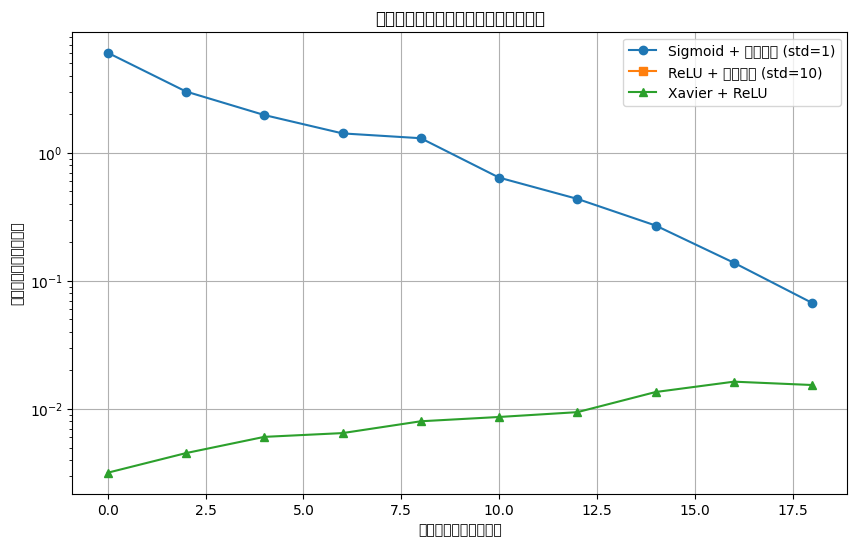

In [8]:
import torch.nn as nn

# --------------------------
# 工具函数：打印各层梯度范数
# --------------------------
def print_grad_norms(model, name):
    print(f"\n===== {name} 各层梯度范数 =====")
    grad_norms = []
    for i, layer in enumerate(model):
        if isinstance(layer, nn.Linear):
            if layer.weight.grad is not None:
                norm = torch.norm(layer.weight.grad, 2).item()
                grad_norms.append(norm)
                print(f"层 {i:2d} | 梯度范数: {norm:.6f}")
            else:
                grad_norms.append(0.0)
                print(f"层 {i:2d} | 梯度范数: 无梯度")
    return grad_norms

# --------------------------
# 1. 构建20层全连接网络
# --------------------------
def build_deep_model(activation_fn, init_func=None, std=None):
    layers = []
    input_dim = 256  # 输入维度
    hidden_dim = 256
    for i in range(20):
        layers.append(nn.Linear(input_dim, hidden_dim))
        if activation_fn is not None:
            layers.append(activation_fn())
        input_dim = hidden_dim
    model = nn.Sequential(*layers)
    
    # 初始化权重
    if init_func is not None:
        for m in model:
            if isinstance(m, nn.Linear):
                if std is not None:
                    init_func(m.weight, mean=0, std=std)
                else:
                    init_func(m.weight)
                nn.init.zeros_(m.bias)
    return model

# --------------------------
# 2. 模拟梯度消失（Sigmoid + 普通高斯初始化）
# --------------------------
print("===== 实验1：Sigmoid + 普通高斯初始化（std=1） =====")
model1 = build_deep_model(nn.Sigmoid, init_func=nn.init.normal_, std=1.0)
x = torch.randn(100, 256)  # 随机输入
y = torch.randint(0, 2, (100,)).float()

# 前向+反向传播
output = model1(x)
loss = nn.MSELoss()(output[:, 0], y)  # 简化损失计算
loss.backward()

# 打印梯度范数
grad_norms1 = print_grad_norms(model1, "Sigmoid + 普通高斯初始化")

# --------------------------
# 3. 模拟梯度爆炸（ReLU + 大初始化std=10）
# --------------------------
print("\n===== 实验2：ReLU + 大初始化（std=10） =====")
model2 = build_deep_model(nn.ReLU, init_func=nn.init.normal_, std=10.0)
x = torch.randn(100, 256)

try:
    output = model2(x)
    loss = output.mean()
    loss.backward()
    grad_norms2 = print_grad_norms(model2, "ReLU + 大初始化")
except RuntimeError as e:
    print(f"出现数值异常: {e}")
    grad_norms2 = [float('inf')] * 20

# --------------------------
# 4. 修复：Xavier初始化 + ReLU
# --------------------------
print("\n===== 实验3：Xavier初始化 + ReLU =====")
model3 = build_deep_model(nn.ReLU, init_func=nn.init.xavier_uniform_)
x = torch.randn(100, 256)

output = model3(x)
loss = nn.MSELoss()(output[:, 0], y)
loss.backward()

grad_norms3 = print_grad_norms(model3, "Xavier初始化 + ReLU")

# --------------------------
# 5. 对比三种情况的梯度范数曲线
# --------------------------
plt.figure(figsize=(10, 6))
layers = list(range(0, 20, 2))  # 只取线性层索引
plt.plot(layers, grad_norms1[::2], marker='o', label='Sigmoid + 普通高斯 (std=1)')
plt.plot(layers, grad_norms2[::2], marker='s', label='ReLU + 大初始化 (std=10)')
plt.plot(layers, grad_norms3[::2], marker='^', label='Xavier + ReLU')

plt.yscale('log')  # 对数坐标更易观察
plt.xlabel('网络层（线性层索引）')
plt.ylabel('梯度范数（对数刻度）')
plt.title('不同初始化与激活函数的梯度范数对比')
plt.legend()
plt.grid(True)
plt.show()

基线模型（无修正）测试MSE: 0.0102
加权修正后模型测试MSE: 0.0240


C:\Users\jimmy\AppData\Local\Temp\ipykernel_5448\267731122.py:82: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jimmy\AppData\Local\Temp\ipykernel_5448\267731122.py:82: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jimmy\AppData\Local\Temp\ipykernel_5448\267731122.py:82: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jimmy\AppData\Local\Temp\ipykernel_5448\267731122.py:82: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jimmy\AppData\Local\Temp\ipykernel_5448\267731122.py:82: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jimmy\AppData\Local\Temp\ipykernel_5448\267731122.py:82: UserWarning: Glyph 27169 (\N{CJK UNIFIE

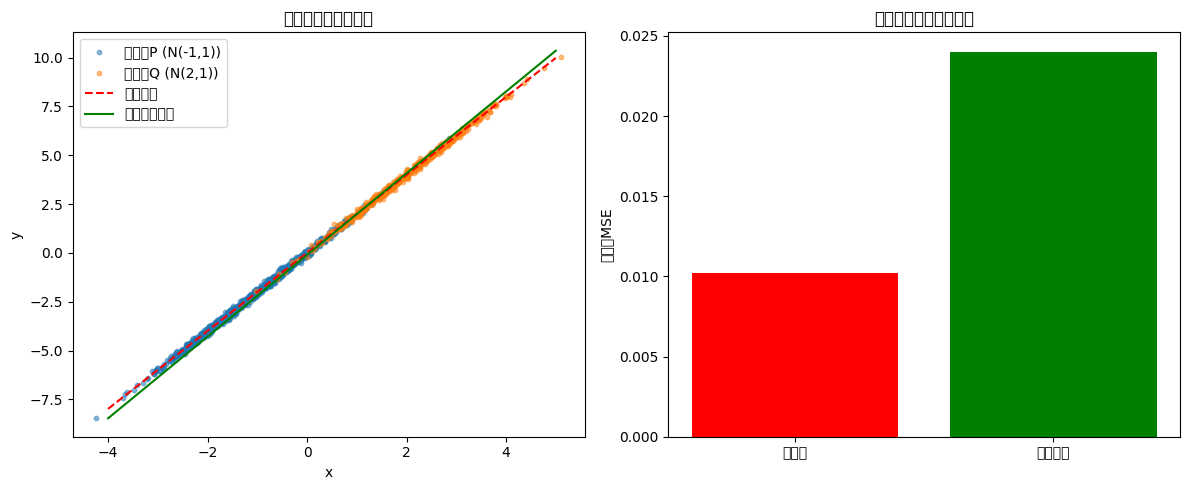

In [9]:
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error
# --------------------------
# 1. 构造数据集（协变量偏移）
# --------------------------
np.random.seed(42)
# 训练集P: x ~ N(-1,1), y = 2x + ε
n_train = 1000
x_train = np.random.normal(loc=-1, scale=1, size=(n_train, 1))
epsilon_train = np.random.normal(loc=0, scale=0.1, size=(n_train, 1))
y_train = 2 * x_train + epsilon_train

# 测试集Q: x ~ N(2,1), y = 2x + ε（协变量偏移）
n_test = 500
x_test = np.random.normal(loc=2, scale=1, size=(n_test, 1))
epsilon_test = np.random.normal(loc=0, scale=0.1, size=(n_test, 1))
y_test = 2 * x_test + epsilon_test

# --------------------------
# 2. 基线模型：直接在P上训练，在Q上评估
# --------------------------
baseline_model = LinearRegression()
baseline_model.fit(x_train, y_train)
y_pred_baseline = baseline_model.predict(x_test)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
print(f"基线模型（无修正）测试MSE: {mse_baseline:.4f}")

# --------------------------
# 3. 偏移校正：训练分类器估计P(test|x)
# --------------------------
# 构造分类任务数据：训练集P标记为0，测试集Q标记为1
x_all = np.vstack([x_train, x_test])
y_domain = np.hstack([np.zeros(n_train), np.ones(n_test)])

# 训练逻辑回归分类器
domain_classifier = LogisticRegression()
domain_classifier.fit(x_all, y_domain)

# 预测训练集样本属于测试集的概率 P(test|x)
p_test_given_x = domain_classifier.predict_proba(x_train)[:, 1]
p_train_given_x = 1 - p_test_given_x  # P(train|x)

# 计算权重 w_i ∝ P(test|x_i) / P(train|x_i)
weights = p_test_given_x / p_train_given_x
weights = weights / np.mean(weights)  # 权重归一化，避免数值过大

# --------------------------
# 4. 加权线性回归模型
# --------------------------
weighted_model = LinearRegression()
weighted_model.fit(x_train, y_train, sample_weight=weights)
y_pred_weighted = weighted_model.predict(x_test)
mse_weighted = mean_squared_error(y_test, y_pred_weighted)
print(f"加权修正后模型测试MSE: {mse_weighted:.4f}")

# --------------------------
# 5. 结果可视化对比
# --------------------------
plt.figure(figsize=(12, 5))

# 左图：数据分布与模型拟合线
plt.subplot(1, 2, 1)
plt.scatter(x_train, y_train, s=10, alpha=0.5, label='训练集P (N(-1,1))')
plt.scatter(x_test, y_test, s=10, alpha=0.5, label='测试集Q (N(2,1))')
# 基线模型线
x_line = np.linspace(-4, 5, 100).reshape(-1, 1)
plt.plot(x_line, baseline_model.predict(x_line), 'r--', label='基线模型')
# 加权模型线
plt.plot(x_line, weighted_model.predict(x_line), 'g-', label='加权修正模型')
plt.xlabel('x')
plt.ylabel('y')
plt.title('数据分布与模型拟合')
plt.legend()

# 右图：修正前后MSE对比
plt.subplot(1, 2, 2)
plt.bar(['无修正', '加权修正'], [mse_baseline, mse_weighted], color=['red', 'green'])
plt.ylabel('测试集MSE')
plt.title('修正前后测试误差对比')

plt.tight_layout()
plt.show()